In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path='mexico-real-estate-combined-clean.csv'
df=pd.read_csv(data_path)
df

,property_type,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,state,lat,lon
0,apartment,875000.00,0.0,263.0,Quintana Roo,21.190264,-86.819838
1,apartment,300000.00,1500.0,160.0,Quintana Roo,20.498783,-87.222819
2,apartment,172446.86,0.0,83.0,Distrito Federal,19.379406,-99.159145
3,apartment,115000.00,49.0,49.0,Quintana Roo,21.051121,-86.782851
4,apartment,70880.12,56.0,56.0,Distrito Federal,19.402413,-99.095391
...,...,...,...,...,...,...,...
2450,house,299000.00,0.0,234.0,Quintana Roo,20.226900,-87.433601
2451,apartment,53967.66,0.0,63.0,Distrito Federal,19.299023,-99.043647
2452,apartment,83264.38,0.0,54.0,Distrito Federal,19.458118,-99.125557
2453,house,2975000.00,762.0,762.0,Distrito Federal,19.420166,-99.220367


In [3]:
corr_price_area=df["surface_covered_in_m2"].corr(df['price_aprox_usd'])
corr_price_area
print(f'The correlation between area and price of property is {corr_price_area}')

The correlation between area and price of property is 0.39200559272553426


In [4]:
corr_matrix = (
    df
    .select_dtypes("number") # to select the numeric data only
    .corr()
)

corr_matrix

,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,lat,lon
price_aprox_usd,1.000000,0.073562,0.392006,-0.033495,-0.046670
surface_total_in_m2,0.073562,1.000000,0.054761,0.059148,0.058524
surface_covered_in_m2,0.392006,0.054761,1.000000,0.012425,0.001048
lat,-0.033495,0.059148,0.012425,1.000000,0.937675
lon,-0.046670,0.058524,0.001048,0.937675,1.000000


Text(0.5, 1.0, 'Correlation Matrix for numerical features of Real Estate Data')

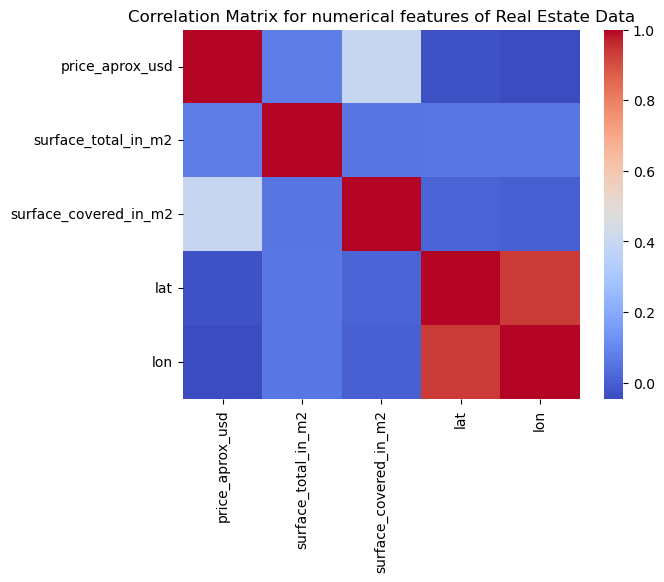

In [5]:
fig,ax=plt.subplots()
sns.heatmap(corr_matrix,cmap='coolwarm',ax=ax)
ax.set_title('Correlation Matrix for numerical features of Real Estate Data')

In [6]:
(df.groupby("state")[['surface_covered_in_m2','price_aprox_usd']]
 .corr()
 .iloc[:,1]
 .xs('surface_covered_in_m2',level=1))


state
Benito Juárez      -0.707185
Distrito Federal    0.594166
Quintana Roo        0.254076
Solidaridad         0.466269
Zacatecas          -0.384412
Name: price_aprox_usd, dtype: float64

In [7]:
(df.groupby('property_type')[['surface_covered_in_m2','price_aprox_usd']]
 .corr()
 .iloc[:,1]
 .xs('surface_covered_in_m2',level=1)
)



property_type
apartment    0.168969
house        0.715827
store        0.705616
Name: price_aprox_usd, dtype: float64

In [8]:
data = (
    df
    .assign(price_per_m2 = lambda x: x['price_aprox_usd'] / x['surface_covered_in_m2'])
)

data.head()
data.shape
data = data[
    (data["surface_covered_in_m2"] < 5000) &
    (data["price_per_m2"] < 20000)
]


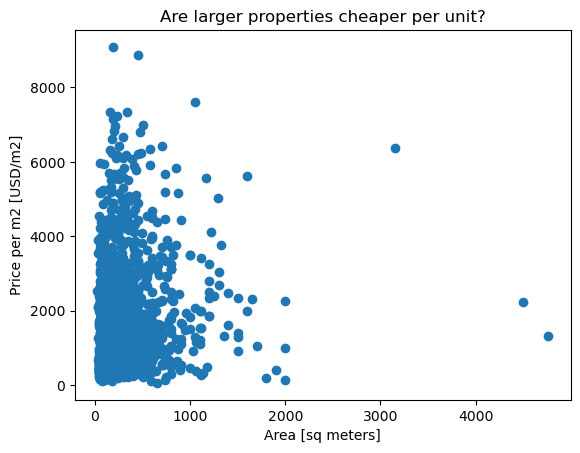

In [9]:
fig, ax = plt.subplots()

# Scatter plot
ax.scatter(x=data["surface_covered_in_m2"], y=data["price_per_m2"],)

ax.set_title("Are larger properties cheaper per unit?")
ax.set_xlabel("Area [sq meters]")
ax.set_ylabel("Price per m2 [USD/m2]")

plt.show()